--- DATASET COVERAGE SUMMARY ---
Total census block groups: 624
Block groups with heat traverse data: 196 (31.4%)
Block groups with canopy data: 624 (100%)
Block groups with income data: 617 (98.9%)

--- DESCRIPTIVE STATISTICS ---
                         mean           std       min           50%  \
canopy_pct_2022     47.144872     13.193679      3.13     48.295000   
median_income    88671.269044  42399.810666  20779.00  79737.000000   
mean_temp_f         94.991936      2.384854     88.48     95.259959   

                           max  
canopy_pct_2022      82.500000  
median_income    250001.000000  
mean_temp_f         100.832353  


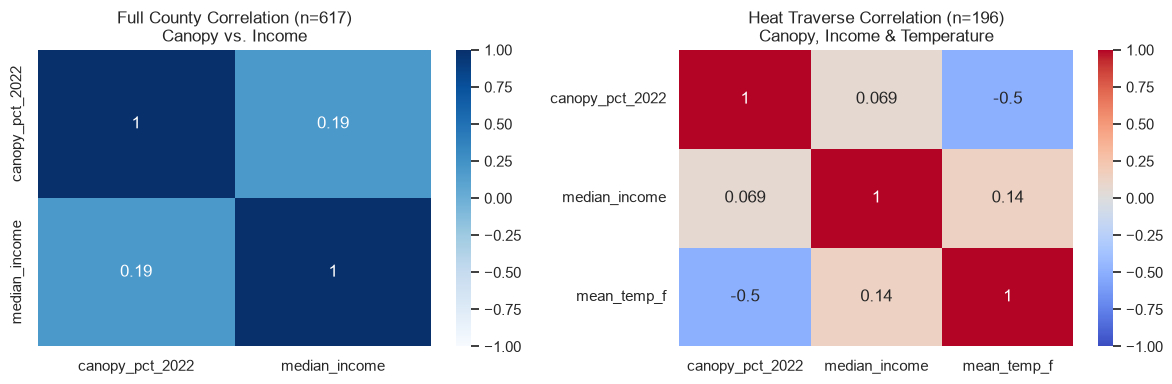

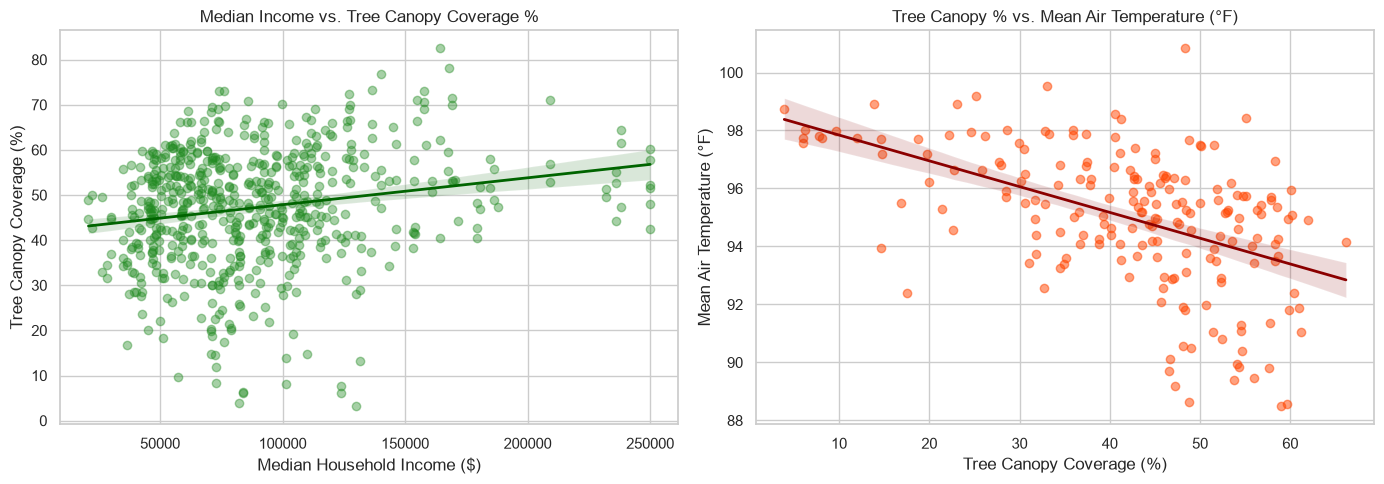

In [4]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path(r"C:\Users\Fiorella\OneDrive\VSCODE PROJECTS\Projects\DTSC 2\Personal Project Part 1")
PROCESSED_DIR = PROJECT_DIR / "notebooks" / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "notebooks" / "output"

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# Load the full analysis dataset and the heat-covered subset.
gdf_analysis = gpd.read_file(
    PROCESSED_DIR / "charlotte_analysis.geojson",
    engine="pyogrio",
)
gdf_heat_subset = gpd.read_file(
    PROCESSED_DIR / "charlotte_analysis_heat_subset.geojson",
    engine="pyogrio",
)

# Use the canonical column names produced by data_cleaning.ipynb.
total_block_groups = len(gdf_analysis)
heat_block_groups = len(gdf_heat_subset)
heat_coverage_pct = heat_block_groups / total_block_groups * 100

print("--- DATASET COVERAGE SUMMARY ---")
print(f"Total census block groups: {total_block_groups}")
print(
    f"Block groups with heat traverse data: {heat_block_groups} "
    f"({heat_coverage_pct:.1f}%)"
)
print(
    f"Block groups with canopy data: "
    f"{gdf_analysis['canopy_pct_2022'].notna().sum()} (100%)"
)
print(
    f"Block groups with income data: "
    f"{gdf_analysis['median_income'].notna().sum()} "
    f"({gdf_analysis['median_income'].notna().mean():.1%})"
)

stats_columns = ["canopy_pct_2022", "median_income", "mean_temp_f"]
print("\n--- DESCRIPTIVE STATISTICS ---")
print(gdf_analysis[stats_columns].describe().T[["mean", "std", "min", "50%", "max"]])

canopy_income = gdf_analysis[["canopy_pct_2022", "median_income"]].dropna()
heat_analysis = gdf_heat_subset[
    ["canopy_pct_2022", "median_income", "mean_temp_f"]
].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(canopy_income.corr(), annot=True, cmap="Blues", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title(f"Full County Correlation (n={len(canopy_income)})\nCanopy vs. Income")
sns.heatmap(heat_analysis.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title(f"Heat Traverse Correlation (n={len(heat_analysis)})\nCanopy, Income & Temperature")
plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "correlation_heatmaps.png", dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(
    data=canopy_income,
    x="median_income",
    y="canopy_pct_2022",
    ax=axes[0],
    scatter_kws={"alpha": 0.4, "color": "forestgreen"},
    line_kws={"color": "darkgreen", "linewidth": 2},
)
axes[0].set_title("Median Income vs. Tree Canopy Coverage %")
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Tree Canopy Coverage (%)")
sns.regplot(
    data=heat_analysis,
    x="canopy_pct_2022",
    y="mean_temp_f",
    ax=axes[1],
    scatter_kws={"alpha": 0.5, "color": "orangered"},
    line_kws={"color": "darkred", "linewidth": 2},
)
axes[1].set_title("Tree Canopy % vs. Mean Air Temperature (°F)")
axes[1].set_xlabel("Tree Canopy Coverage (%)")
axes[1].set_ylabel("Mean Air Temperature (°F)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bivariate_scatterplots.png", dpi=300)
plt.show()

In [2]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import statsmodels.formula.api as smf

# Model the relationship using canonical analysis columns.
df_model = gdf_heat_subset.dropna(
    subset=["mean_temp_f", "canopy_pct_2022", "median_income"]
).copy()
df_model["log_median_income"] = np.log(df_model["median_income"])

model = smf.ols(
    "mean_temp_f ~ canopy_pct_2022 + log_median_income",
    data=df_model,
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              mean_temp   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     35.29
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           8.65e-14
Time:                        23:27:06   Log-Likelihood:                -417.42
No. Observations:                 196   AIC:                             840.8
Df Residuals:                     193   BIC:                             850.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                91.10